In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

# ─── Load ─────────────────────────────────────────────────────────────────────

hpc = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_kbind_kunbind_10x10_HPC.csv.gz", compression="gzip")
hpc["kills_per_synapse"] = hpc["kills_per_synapse"].fillna(0)



In [ ]:
# mean kills/synapse across seeds

pivot = (
    hpc.groupby(["k_bind", "k_unbind"])["kills_per_synapse"]
    .mean()
    .unstack(level="k_unbind")
)
k_bind_vals   = pivot.index.tolist()
k_unbind_vals = pivot.columns.tolist()

def _fmt(v):
    return str(int(v)) if v >= 1 else str(v)

row_labels = [_fmt(v) for v in k_bind_vals]
col_labels = [_fmt(v) for v in k_unbind_vals]

Z = pivot.values   # shape (10, 10), rows = k_bind, cols = k_unbind


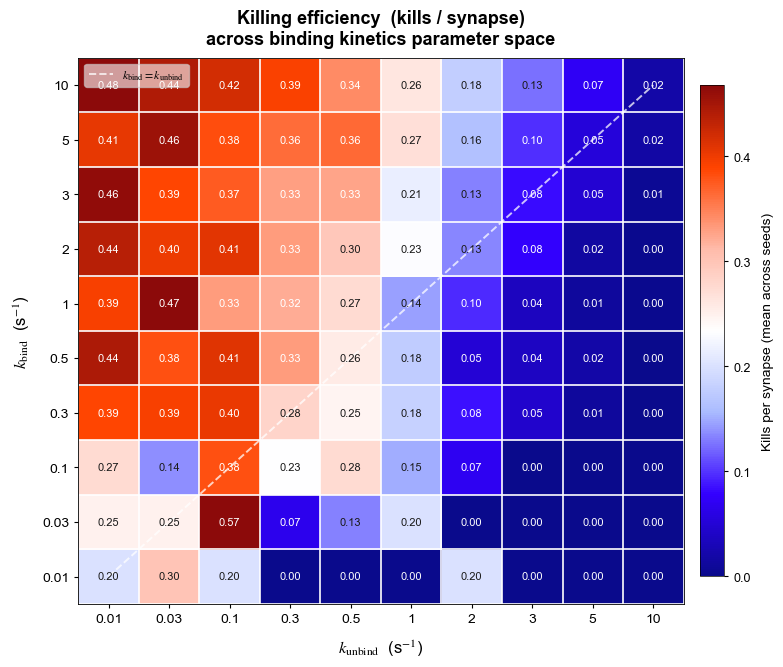

Saved: plot_kbind_kunbind_heatmap.png


In [ ]:
plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family":      "Arial",
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   13,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})
cmap = LinearSegmentedColormap.from_list(
    "bwr_custom",
    ["#0a0a8c", "#3300FF", "#aabbff", "#ffffff", "#ffbbaa", "#FF4400", "#8c0a0a"],
    N=256,
)

fig, ax = plt.subplots(figsize=(8.5, 7.0))
fig.subplots_adjust(left=0.12, right=0.88, top=0.90, bottom=0.12)

vmax = np.nanpercentile(Z, 98)
vmin = 0

im = ax.imshow(
    Z,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest",
)

# annotations

for row_i in range(Z.shape[0]):
    for col_i in range(Z.shape[1]):
        val = Z[row_i, col_i]
        norm_val = (val - vmin) / (vmax - vmin) if vmax > vmin else 0
        txt_colour = "white" if (norm_val > 0.65 or norm_val < 0.25) else "#1a1a1a"
        ax.text(
            col_i, row_i,
            f"{val:.2f}",
            ha="center", va="center",
            fontsize=8.0, color=txt_colour,
            fontweight="normal",
        )


ax.set_xticks(np.arange(len(k_unbind_vals)))
ax.set_yticks(np.arange(len(k_bind_vals)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

ax.set_xlabel(r"$k_{\mathrm{unbind}}$  (s$^{-1}$)", labelpad=8)
ax.set_ylabel(r"$k_{\mathrm{bind}}$  (s$^{-1}$)", labelpad=8)

ax.set_title(
    "Killing efficiency  (kills / synapse)\nacross binding kinetics parameter space",
    fontweight="semibold", pad=10,
)

ax.set_xticks(np.arange(-0.5, len(k_unbind_vals), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(k_bind_vals),   1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", length=0)
ax.tick_params(which="major", length=3, width=0.8)

for spine in ax.spines.values():
    spine.set_linewidth(0.6)

cbar = fig.colorbar(im, ax=ax, fraction=0.038, pad=0.025)
cbar.set_label("Kills per synapse (mean across seeds)", labelpad=8, fontsize=10)
cbar.ax.tick_params(labelsize=9, length=3)
cbar.outline.set_linewidth(0.5)

bind_arr   = np.array(k_bind_vals)
unbind_arr = np.array(k_unbind_vals)

diag_pts = []
for row_i, kb in enumerate(bind_arr):
    col_i_exact = np.interp(
        np.log10(kb),
        np.log10(unbind_arr),
        np.arange(len(unbind_arr)),
    )
    diag_pts.append((col_i_exact, row_i))

diag_x, diag_y = zip(*diag_pts)
ax.plot(
    diag_x, diag_y,
    color="white", linewidth=1.4, linestyle="--",
    alpha=0.75, label=r"$k_{\mathrm{bind}} = k_{\mathrm{unbind}}$",
)
ax.legend(
    loc="upper left", fontsize=8.5, frameon=True,
    framealpha=0.6, edgecolor="#cccccc",
)

plt.savefig("plot_kbind_kunbind_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot_kbind_kunbind_heatmap.png")